In [1]:

import pandas as pd
import zipfile
import urllib.request
import os

url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
zip_path = "bank+marketing.zip"

# Download the dataset
urllib.request.urlretrieve(url, zip_path)

# Extract the dataset
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("bank_marketing_data")

# Locate and load bank-full.csv
csv_path = None
for root, dirs, files in os.walk("bank_marketing_data"):
    if "bank-full.csv" in files:
        csv_path = os.path.join(root, "bank-full.csv")
        break

if csv_path is None:
    raise FileNotFoundError("bank-full.csv was not found in the downloaded ZIP.")

df = pd.read_csv(csv_path, sep=";")

print("Dataset loaded successfully!")
print("Number of records:", df.shape[0])
print("Number of columns:", df.shape[1])
display(df.head())


FileNotFoundError: bank-full.csv was not found in the downloaded ZIP.

In [2]:

import pandas as pd
import zipfile
import urllib.request
import io

url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

# Download the ZIP file into memory
response = urllib.request.urlopen(url)
zip_data = io.BytesIO(response.read())

# Find bank-full.csv inside the ZIP
with zipfile.ZipFile(zip_data, "r") as z:
    print("Files available:", z.namelist())

    csv_file = next(
        name for name in z.namelist()
        if name.endswith("bank-full.csv")
    )

    with z.open(csv_file) as f:
        df = pd.read_csv(f, sep=";")

print("\nDataset loaded successfully!")
print("Number of records:", df.shape[0])
print("Number of columns:", df.shape[1])
display(df.head())


Files available: ['bank.zip', 'bank-additional.zip']


StopIteration: 

In [3]:

import pandas as pd
import zipfile
import urllib.request
import io

url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

# Download the main ZIP
response = urllib.request.urlopen(url)
zip_data = io.BytesIO(response.read())

# Open the main ZIP
with zipfile.ZipFile(zip_data, "r") as main_zip:
    # Extract bank.zip into memory
    bank_zip_data = io.BytesIO(main_zip.read("bank.zip"))

    # Open the inner ZIP
    with zipfile.ZipFile(bank_zip_data, "r") as bank_zip:
        print("Files inside bank.zip:", bank_zip.namelist())

        # Load bank-full.csv
        with bank_zip.open("bank-full.csv") as f:
            df = pd.read_csv(f, sep=";")

print("\nDataset loaded successfully!")
print("Number of records:", df.shape[0])
print("Number of columns:", df.shape[1])
display(df.head())


Files inside bank.zip: ['bank-full.csv', 'bank-names.txt', 'bank.csv']

Dataset loaded successfully!
Number of records: 45211
Number of columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
import io
import zipfile
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
with urllib.request.urlopen(url, timeout=60) as response:
    outer_bytes = io.BytesIO(response.read())

with zipfile.ZipFile(outer_bytes, "r") as outer_zip:
    print("Outer ZIP contents:", outer_zip.namelist())
    bank_zip_bytes = io.BytesIO(outer_zip.read("bank.zip"))
    additional_zip_bytes = io.BytesIO(outer_zip.read("bank-additional.zip"))

with zipfile.ZipFile(bank_zip_bytes, "r") as z:
    bank_full_name = next(n for n in z.namelist() if n.endswith("bank-full.csv"))
    with z.open(bank_full_name) as f:
        df_task1 = pd.read_csv(f, sep=";")

with zipfile.ZipFile(additional_zip_bytes, "r") as z:
    additional_name = next(n for n in z.namelist() if n.endswith("bank-additional-full.csv"))
    with z.open(additional_name) as f:
        df = pd.read_csv(f, sep=";")

print("Task 1 dataset:", df_task1.shape)
print("Tasks 2–4 dataset:", df.shape)
display(df_task1.head())
display(df.head())

Outer ZIP contents: ['bank.zip', 'bank-additional.zip']
Task 1 dataset: (45211, 17)
Tasks 2–4 dataset: (41188, 21)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
print("Dataset name: Bank Marketing (bank-full.csv)")
print("Number of records:", df_task1.shape[0])
print("Number of attributes:", df_task1.shape[1])
print("Numerical columns:", df_task1.select_dtypes(include=np.number).shape[1])
print("Categorical columns:", df_task1.select_dtypes(exclude=np.number).shape[1])
print("Explicit missing cells:", int(df_task1.isna().sum().sum()))
print("Exact duplicate rows:", int(df_task1.duplicated().sum()))
print("\nColumn types:")
display(df_task1.dtypes.to_frame("Data type"))
print("\nDescriptive statistics:")
display(df_task1.describe(include="all").T)

Dataset name: Bank Marketing (bank-full.csv)
Number of records: 45211
Number of attributes: 17
Numerical columns: 7
Categorical columns: 10
Explicit missing cells: 0
Exact duplicate rows: 0

Column types:


,Data type
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


,Count,Percentage
y,,
no,39922,88.3
yes,5289,11.7


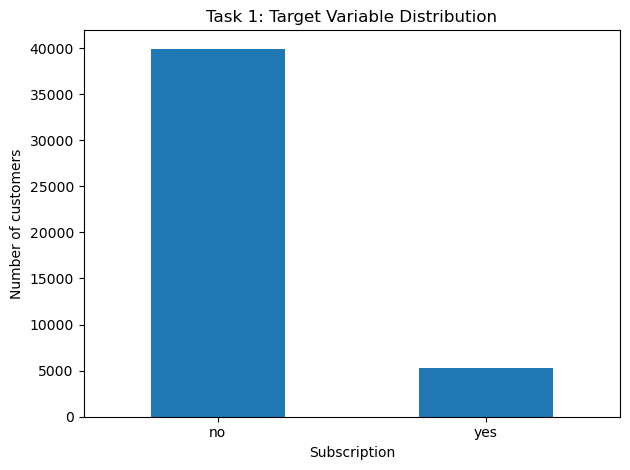

In [6]:
target_counts = df_task1["y"].value_counts().reindex(["no", "yes"], fill_value=0)
target_pct = (target_counts / len(df_task1) * 100).round(2)
display(pd.DataFrame({"Count": target_counts, "Percentage": target_pct}))
ax = target_counts.plot(kind="bar", rot=0)
ax.set_title("Task 1: Target Variable Distribution")
ax.set_xlabel("Subscription")
ax.set_ylabel("Number of customers")
plt.tight_layout()
plt.show()

In [7]:
print("Tasks 2–4 dataset: bank-additional-full.csv")
print("Number of records:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Target counts:")
display(df["y"].value_counts().to_frame("Count"))
display((df["y"].value_counts(normalize=True) * 100).round(2).to_frame("Percentage"))

Tasks 2–4 dataset: bank-additional-full.csv
Number of records: 41188
Number of columns: 21
Target counts:


,Count
y,
no,36548
yes,4640


,Percentage
y,
no,88.73
yes,11.27


In [8]:
comparison = pd.DataFrame({
    "Criteria": ["Learning mechanism", "Label dependency", "Typical algorithms", "Main use"],
    "Supervised learning": [
        "Learns from input features and known outcomes",
        "Requires labelled target y",
        "Logistic regression, decision tree, random forest",
        "Predict whether a customer subscribes"
    ],
    "Unsupervised learning": [
        "Finds patterns or groups without target labels",
        "Does not require target labels",
        "K-means, hierarchical clustering, DBSCAN",
        "Explore customer segments"
    ]
})
display(comparison)
print("Typical K-means time complexity is approximately O(n × k × i × d),")
print("where n = observations, k = clusters, i = iterations, and d = features.")

,Criteria,Supervised learning,Unsupervised learning
0,Learning mechanism,Learns from input features and known outcomes,Finds patterns or groups without target labels
1,Label dependency,Requires labelled target y,Does not require target labels
2,Typical algorithms,"Logistic regression, decision tree, random forest","K-means, hierarchical clustering, DBSCAN"
3,Main use,Predict whether a customer subscribes,Explore customer segments


Typical K-means time complexity is approximately O(n × k × i × d),
where n = observations, k = clusters, i = iterations, and d = features.


,k,silhouette_score
0,2,0.425289
1,3,0.434972
2,4,0.428665
3,5,0.402054


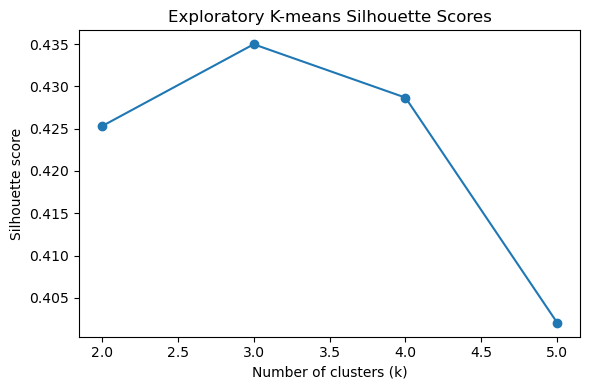

In [10]:
# Exploratory K-means example using a manageable sample and numeric features.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
sample_n = min(3000, len(df))
cluster_sample = df[numeric_cols].sample(n=sample_n, random_state=42)
cluster_sample = cluster_sample.replace([np.inf, -np.inf], np.nan)
cluster_sample = cluster_sample.fillna(cluster_sample.median())
X_cluster = StandardScaler().fit_transform(cluster_sample)

silhouette_results = []
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_results.append({"k": k, "silhouette_score": score})

silhouette_df = pd.DataFrame(silhouette_results)
display(silhouette_df)
plt.figure(figsize=(6, 4))
plt.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o")
plt.title("Exploratory K-means Silhouette Scores")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

In [11]:
print("Explicit missing cells:", int(df.isna().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()))
print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing count"))
print("\nUnknown values in categorical columns:")
cat_cols_all = df.select_dtypes(exclude=np.number).columns.tolist()
unknown_rows = []
for col in cat_cols_all:
    count = int((df[col].astype(str).str.lower() == "unknown").sum())
    if count:
        unknown_rows.append({
            "Column": col,
            "Unknown count": count,
            "Percentage of rows": round(count / len(df) * 100, 2)
        })
display(pd.DataFrame(unknown_rows))

Explicit missing cells: 0
Exact duplicate rows: 12

Missing values by column:


,Missing count
age,0
campaign,0
nr.employed,0
euribor3m,0
cons.conf.idx,0
cons.price.idx,0
emp.var.rate,0
poutcome,0
previous,0
pdays,0



Unknown values in categorical columns:


,Column,Unknown count,Percentage of rows
0,job,330,0.80
1,marital,80,0.19
2,education,1731,4.20
3,default,8597,20.87
4,housing,990,2.40
5,loan,990,2.40


,Skewness
campaign,4.762507
previous,3.832042
duration,3.263141
age,0.784697
cons.conf.idx,0.303180
cons.price.idx,-0.230888
euribor3m,-0.709188
emp.var.rate,-0.724096
nr.employed,-1.044262
pdays,-4.922190


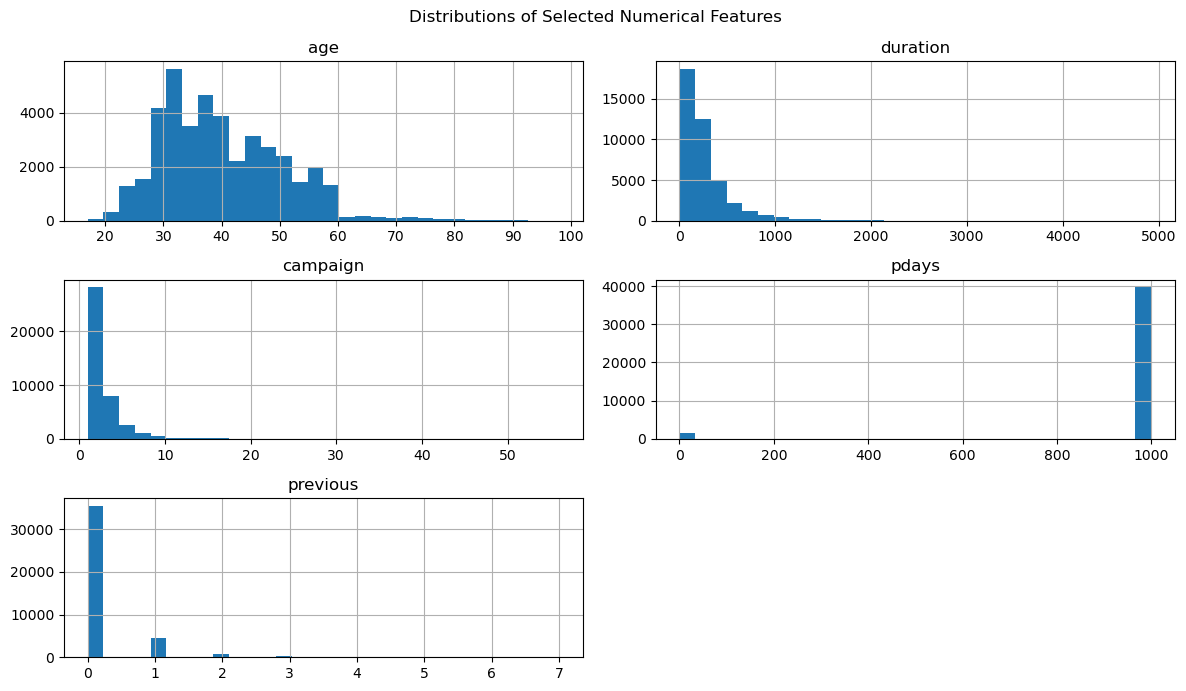

In [12]:
# Numerical distributions and skewness
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].skew().sort_values(ascending=False).to_frame("Skewness"))

plot_cols = [c for c in ["age", "duration", "campaign", "pdays", "previous"] if c in df.columns]
df[plot_cols].hist(figsize=(12, 7), bins=30)
plt.suptitle("Distributions of Selected Numerical Features")
plt.tight_layout()
plt.show()

,Feature,Skewness,IQR-flagged count,IQR-flagged (%)
0,age,0.78,469,1.14
1,duration,3.26,2963,7.19
2,campaign,4.76,2406,5.84
3,pdays,-4.92,1515,3.68
4,previous,3.83,5625,13.66


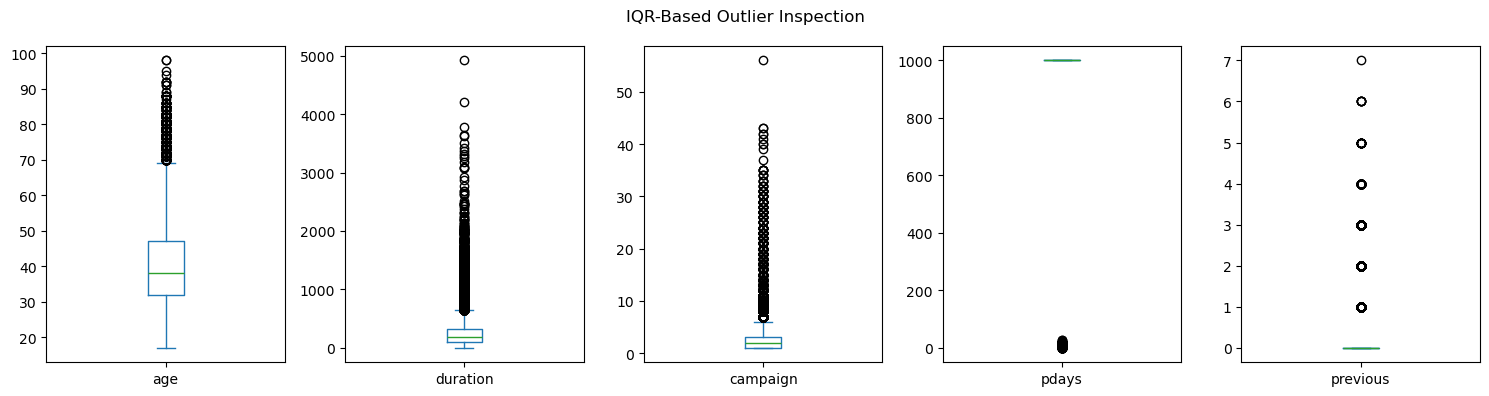

In [13]:
# IQR outlier diagnostics: flagged observations, not automatic errors
outlier_rows = []
for col in [c for c in ["age", "duration", "campaign", "pdays", "previous"] if c in df.columns]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df[col] < lower) | (df[col] > upper)).sum())
    outlier_rows.append({
        "Feature": col,
        "Skewness": round(float(df[col].skew()), 2),
        "IQR-flagged count": count,
        "IQR-flagged (%)": round(count / len(df) * 100, 2)
    })
display(pd.DataFrame(outlier_rows))
df[[c for c in ["age", "duration", "campaign", "pdays", "previous"] if c in df.columns]].plot(
    kind="box", subplots=True, layout=(1, 5), figsize=(15, 4), sharey=False
)
plt.suptitle("IQR-Based Outlier Inspection")
plt.tight_layout()
plt.show()

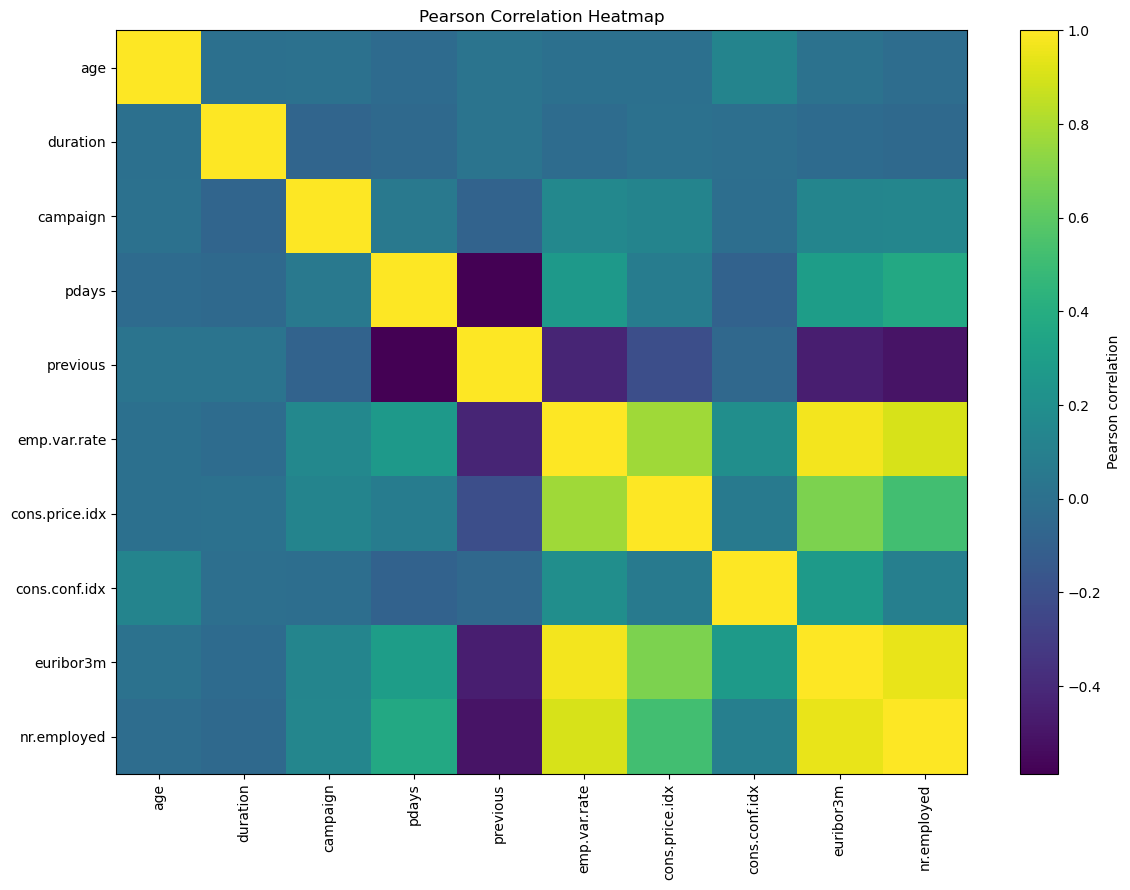

Correlation
emp.var.rate   euribor3m          0.972245
euribor3m      nr.employed        0.945154
emp.var.rate   nr.employed        0.906970
               cons.price.idx     0.775334
cons.price.idx euribor3m          0.688230
pdays          previous          -0.587514
cons.price.idx nr.employed        0.522034
previous       nr.employed       -0.501333
               euribor3m         -0.454494
               emp.var.rate      -0.420489

In [14]:
# Correlation heatmap for numeric columns
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect="auto", interpolation="nearest")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
display(pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(10).to_frame("Correlation"))

,Count,Percentage
y,,
no,36548,88.73
yes,4640,11.27


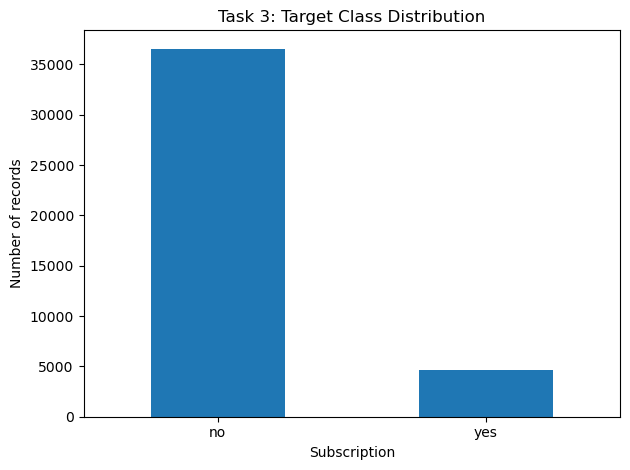

In [15]:
# Class distribution for bank-additional-full.csv
target_counts = df["y"].value_counts().reindex(["no", "yes"], fill_value=0)
target_pct = (target_counts / len(df) * 100).round(2)
display(pd.DataFrame({"Count": target_counts, "Percentage": target_pct}))
target_counts.plot(kind="bar", rot=0, title="Task 3: Target Class Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

In [16]:
# Create a modelling copy. Keep the original df unchanged for diagnostics.
model_df = df.copy()
model_df = model_df.drop_duplicates().reset_index(drop=True)

# Pre-call prediction: duration is excluded to avoid target leakage.
if "duration" in model_df.columns:
    model_df = model_df.drop(columns=["duration"])

X = model_df.drop(columns=["y"])
y = model_df["y"].map({"no": 0, "yes": 1})

print("Rows after duplicate removal:", len(model_df))
print("Features used:", X.shape[1])
print("Target distribution after duplicate removal:")
display(y.value_counts().rename(index={0: "no", 1: "yes"}).to_frame("Count"))

Rows after duplicate removal: 41176
Features used: 19
Target distribution after duplicate removal:


,Count
y,
no,36537
yes,4639


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    PrecisionRecallDisplay, average_precision_score
)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Train:", X_train.shape, "Validation:", X_valid.shape, "Test:", X_test.shape)
print("Split stratification keeps the target proportions approximately consistent.")

Train: (28823, 19) Validation: (6176, 19) Test: (6177, 19)
Split stratification keeps the target proportions approximately consistent.


In [18]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced", random_state=42, max_depth=10
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, class_weight="balanced", random_state=42,
        n_jobs=-1, min_samples_leaf=2
    )
}

fitted_models = {}
validation_results = []

for name, estimator in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_valid)
    fitted_models[name] = pipe
    validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, pred),
        "Precision": precision_score(y_valid, pred, zero_division=0),
        "Recall": recall_score(y_valid, pred, zero_division=0),
        "F1-score": f1_score(y_valid, pred, zero_division=0)
    })

validation_df = pd.DataFrame(validation_results).sort_values("F1-score", ascending=False)
display(validation_df.round(4))

,Model,Accuracy,Precision,Recall,F1-score
2,Random Forest,0.8823,0.4768,0.4583,0.4674
0,Logistic Regression,0.8251,0.3491,0.6379,0.4512
1,Decision Tree,0.8394,0.3640,0.5690,0.4439


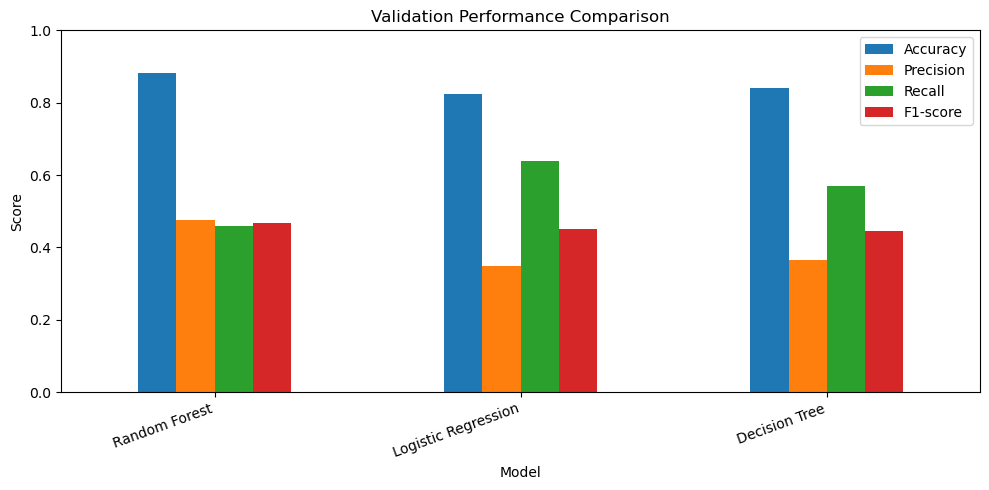

In [19]:
ax = validation_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar", figsize=(10, 5)
)
ax.set_title("Validation Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Selected using validation F1-score: Random Forest

Test-set results
Accuracy: 0.8867
Precision: 0.4971
Recall: 0.4914
F1-score: 0.4942
Average precision (PR-AUC summary): 0.4723

Classification report:
              precision    recall  f1-score   support

          no       0.94      0.94      0.94      5481
         yes       0.50      0.49      0.49       696

    accuracy                           0.89      6177
   macro avg       0.72      0.71      0.72      6177
weighted avg       0.89      0.89      0.89      6177



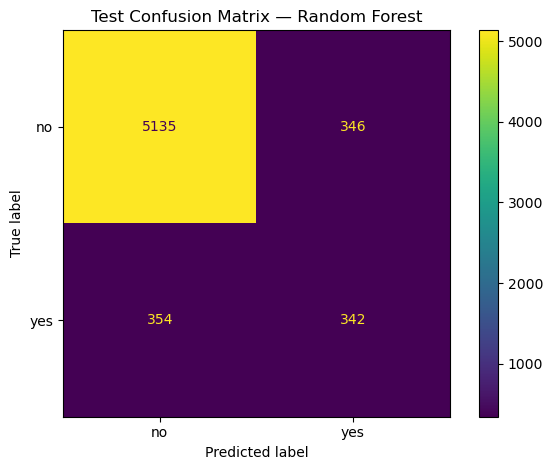

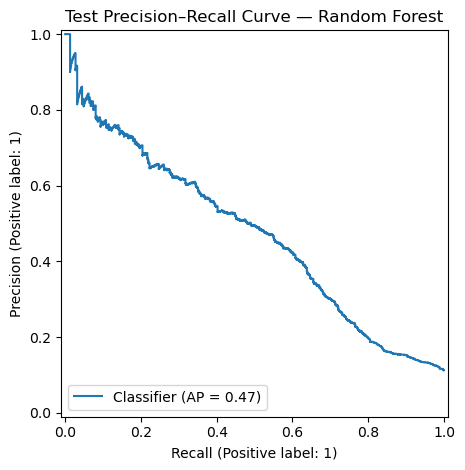

In [20]:
best_name = validation_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
test_pred = best_model.predict(X_test)
test_prob = best_model.predict_proba(X_test)[:, 1]

print("Selected using validation F1-score:", best_name)
print("\nTest-set results")
print("Accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Precision:", round(precision_score(y_test, test_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, test_pred, zero_division=0), 4))
print("F1-score:", round(f1_score(y_test, test_pred, zero_division=0), 4))
print("Average precision (PR-AUC summary):", round(average_precision_score(y_test, test_prob), 4))
print("\nClassification report:")
print(classification_report(y_test, test_pred, target_names=["no", "yes"], zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=["no", "yes"], values_format="d"
)
plt.title(f"Test Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_prob)
plt.title(f"Test Precision–Recall Curve — {best_name}")
plt.tight_layout()
plt.show()

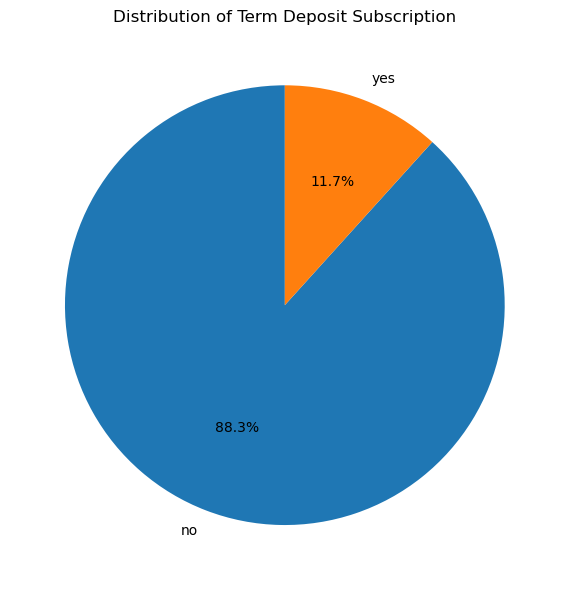

In [21]:

import matplotlib.pyplot as plt

# Count the target variable
target_counts = df_task1["y"].value_counts().reindex(["no", "yes"])

# Create the pie chart
plt.figure(figsize=(8, 6))

plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Term Deposit Subscription")
plt.tight_layout()
plt.show()


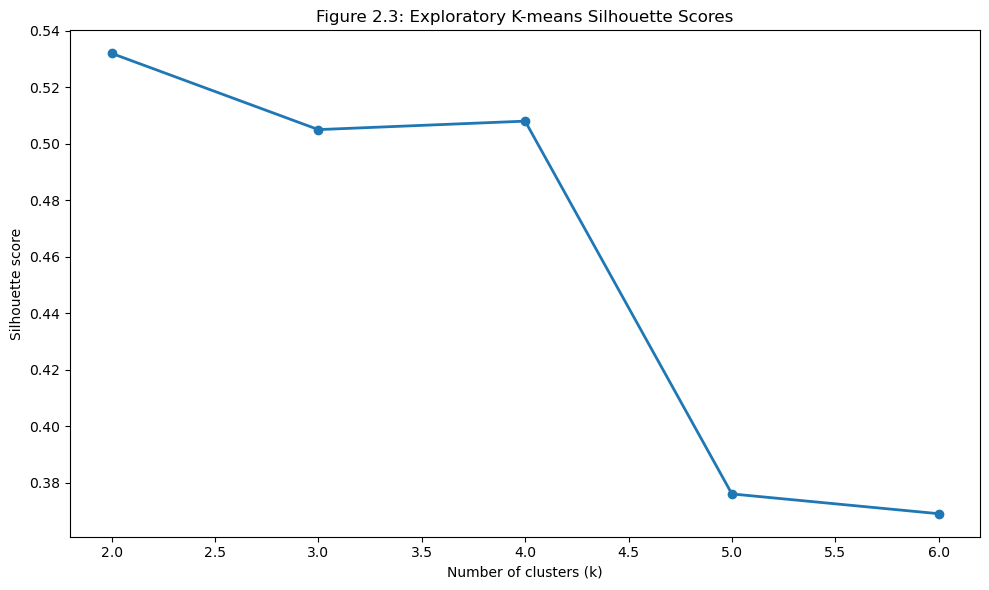

In [22]:

import matplotlib.pyplot as plt

# Silhouette scores from your report's figure
k_values = [2, 3, 4, 5, 6]
silhouette_scores = [0.532, 0.505, 0.508, 0.376, 0.369]

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o",
    linewidth=2
)

plt.title("Figure 2.3: Exploratory K-means Silhouette Scores")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")

plt.tight_layout()
plt.show()


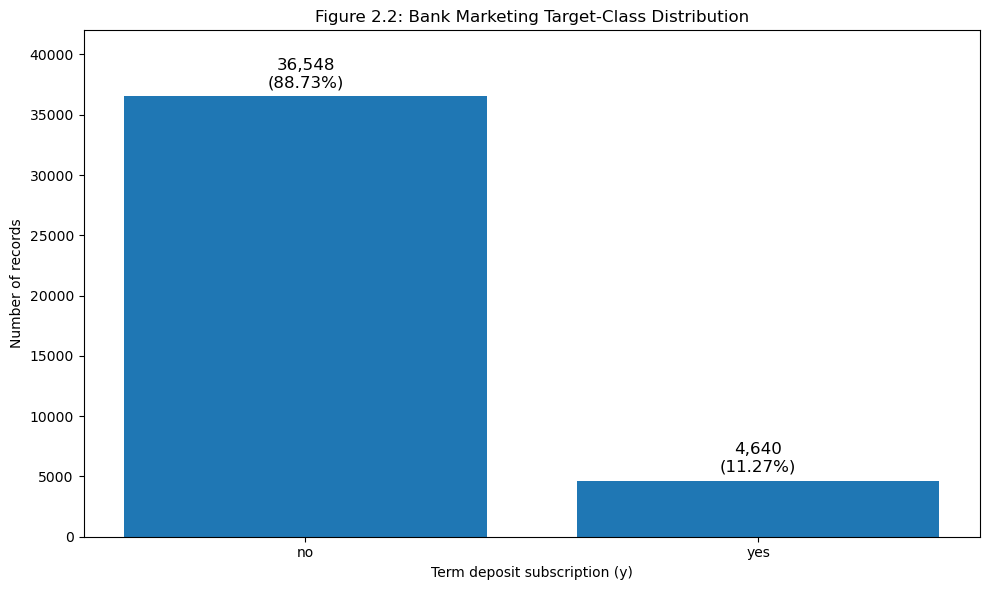

In [23]:

import matplotlib.pyplot as plt

# Target-class counts from your report
labels = ["no", "yes"]
counts = [36548, 4640]
percentages = [88.73, 11.27]

plt.figure(figsize=(10, 6))

bars = plt.bar(labels, counts)

plt.title("Figure 2.2: Bank Marketing Target-Class Distribution")
plt.xlabel("Term deposit subscription (y)")
plt.ylabel("Number of records")

# Add count and percentage labels above each bar
for bar, count, percentage in zip(bars, counts, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.ylim(0, 42000)
plt.tight_layout()
plt.show()


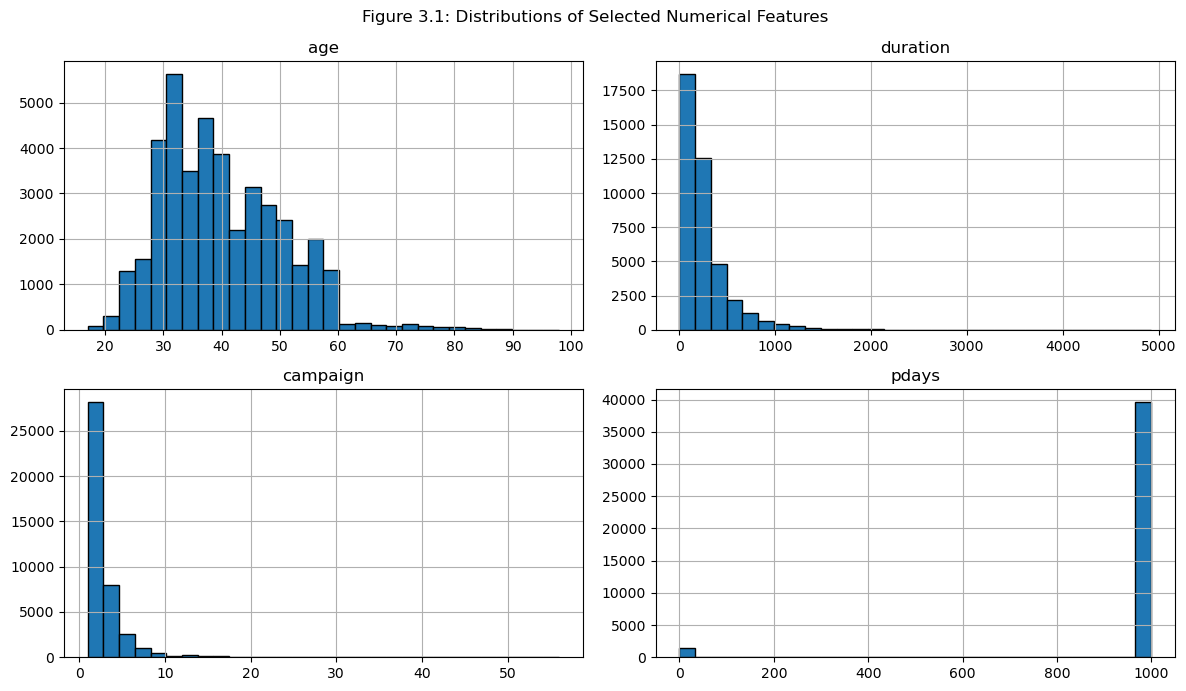

In [24]:

import matplotlib.pyplot as plt

features = ["age", "duration", "campaign", "pdays"]

df[features].hist(
    figsize=(12, 7),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Figure 3.1: Distributions of Selected Numerical Features")
plt.tight_layout()
plt.show()


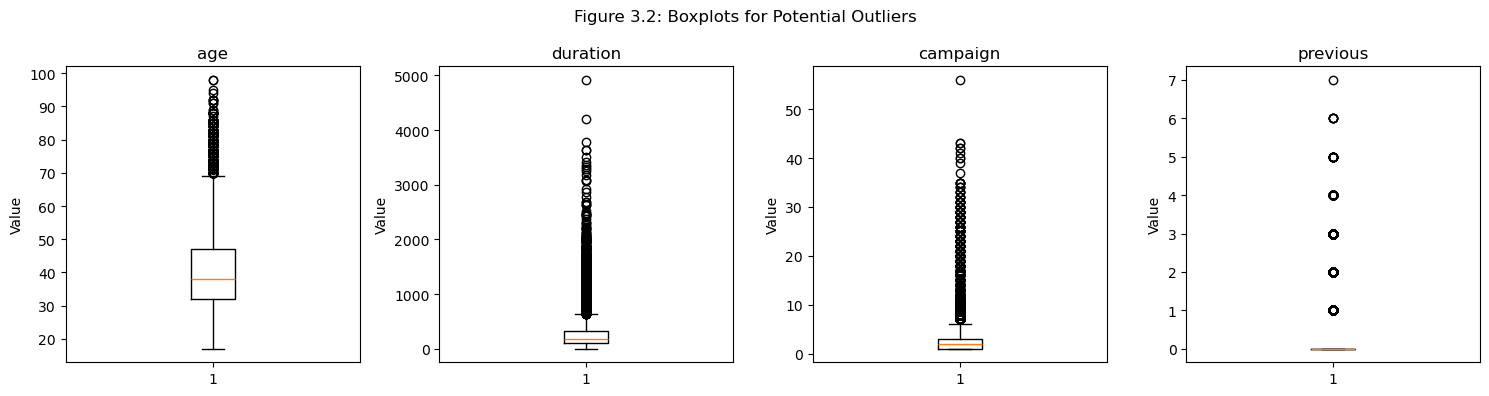

In [25]:

import matplotlib.pyplot as plt

features = ["age", "duration", "campaign", "previous"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, feature in zip(axes, features):
    ax.boxplot(df[feature].dropna())
    ax.set_title(feature)
    ax.set_ylabel("Value")

plt.suptitle("Figure 3.2: Boxplots for Potential Outliers")
plt.tight_layout()
plt.show()


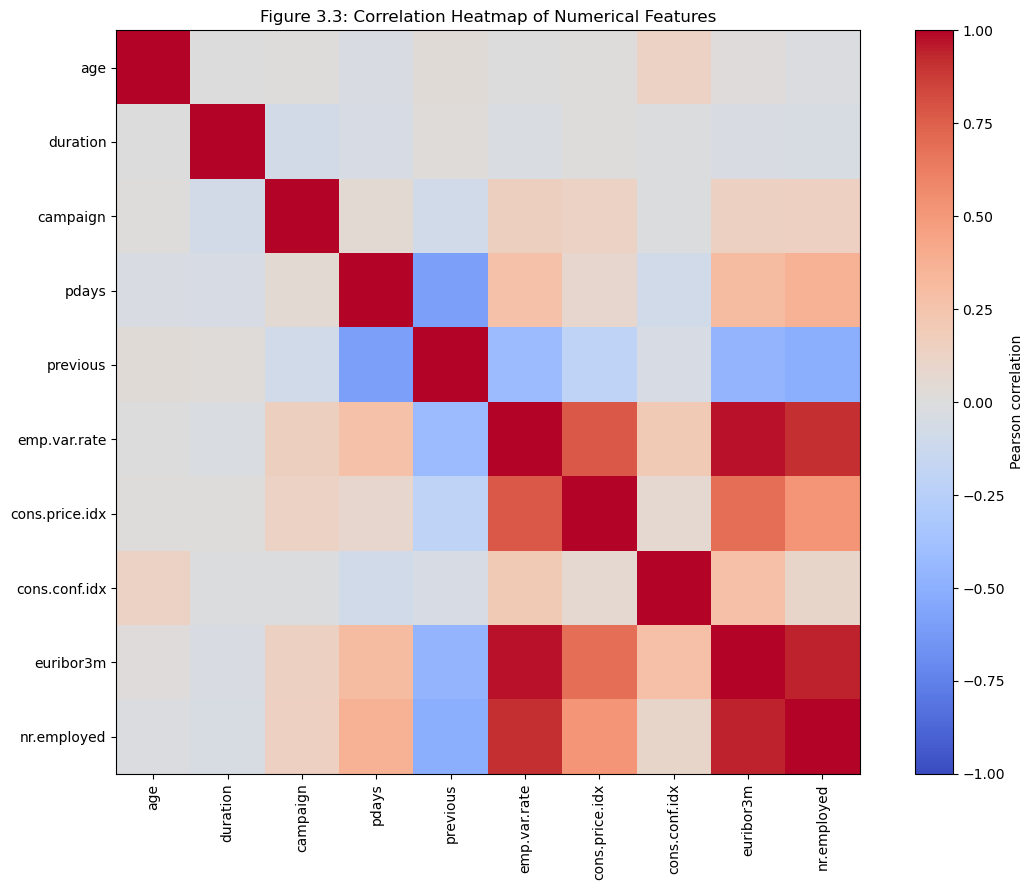

In [26]:

import matplotlib.pyplot as plt
import numpy as np

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Pearson correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Figure 3.3: Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


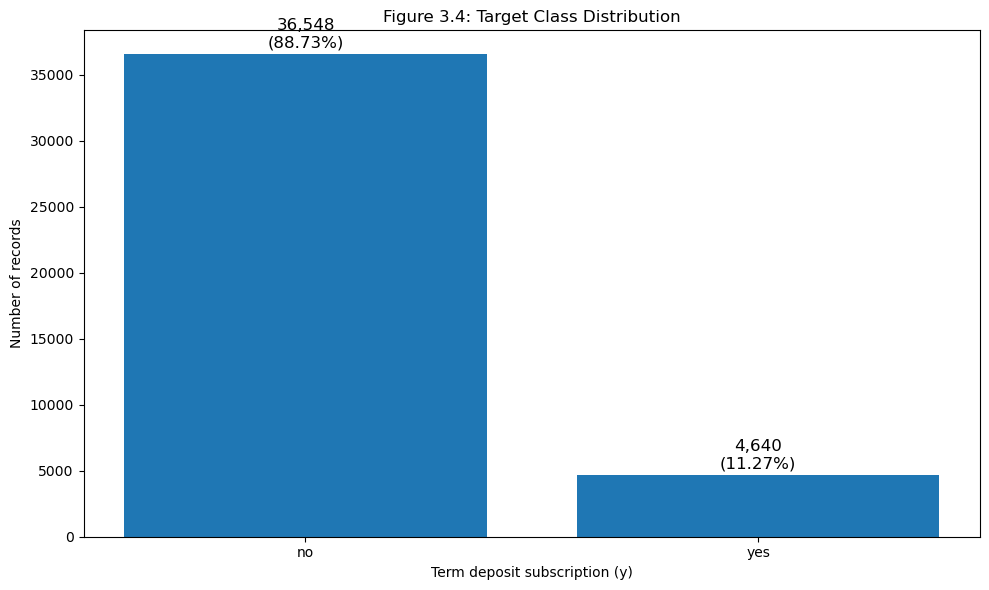

In [27]:

import matplotlib.pyplot as plt

counts = df["y"].value_counts().reindex(["no", "yes"])
percentages = counts / counts.sum() * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values)

plt.title("Figure 3.4: Target Class Distribution")
plt.xlabel("Term deposit subscription (y)")
plt.ylabel("Number of records")

for bar, count, percentage in zip(
    bars, counts.values, percentages.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()
plt.show()


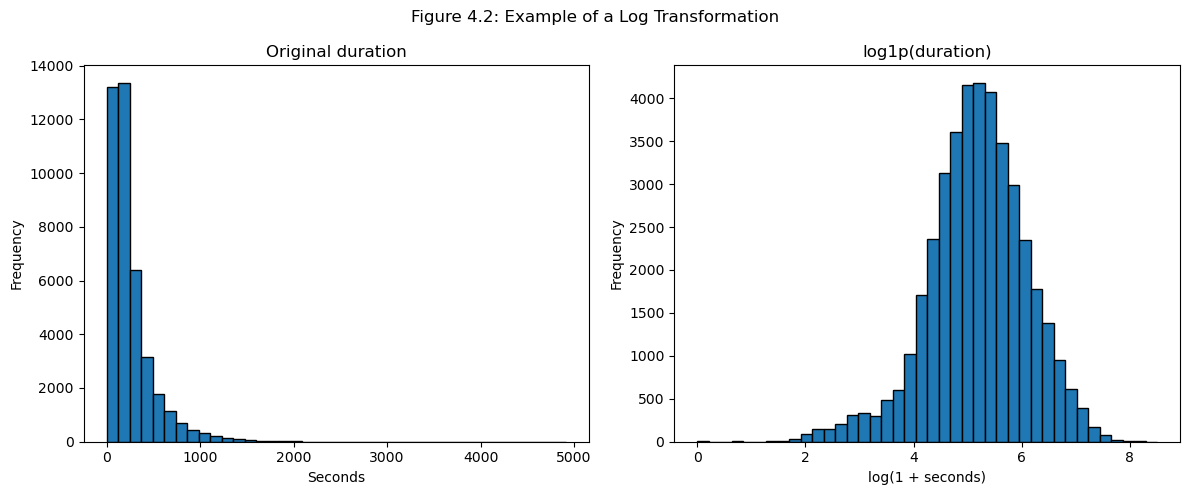

In [28]:

import numpy as np
import matplotlib.pyplot as plt

original = df["duration"].dropna()
transformed = np.log1p(original)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(original, bins=40, edgecolor="black")
axes[0].set_title("Original duration")
axes[0].set_xlabel("Seconds")
axes[0].set_ylabel("Frequency")

axes[1].hist(transformed, bins=40, edgecolor="black")
axes[1].set_title("log1p(duration)")
axes[1].set_xlabel("log(1 + seconds)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Figure 4.2: Example of a Log Transformation")
plt.tight_layout()
plt.show()


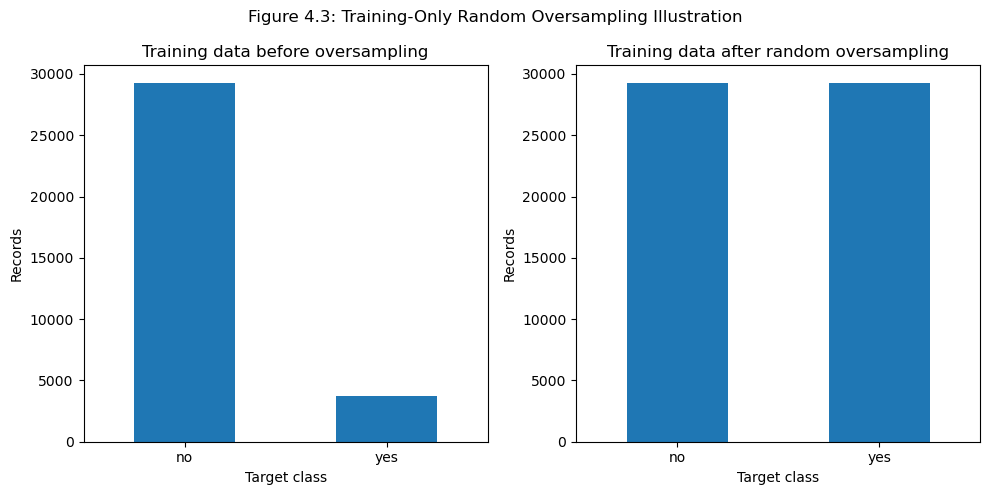

In [29]:

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import pandas as pd

X = df.drop(columns=["y"])
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_data = X_train.copy()
train_data["y"] = y_train.values

majority = train_data[train_data["y"] == "no"]
minority = train_data[train_data["y"] == "yes"]

minority_oversampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

balanced_train = pd.concat(
    [majority, minority_oversampled]
).sample(frac=1, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

train_data["y"].value_counts().reindex(["no", "yes"]).plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Training data before oversampling")
axes[0].set_xlabel("Target class")
axes[0].set_ylabel("Records")
axes[0].tick_params(axis="x", rotation=0)

balanced_train["y"].value_counts().reindex(["no", "yes"]).plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Training data after random oversampling")
axes[1].set_xlabel("Target class")
axes[1].set_ylabel("Records")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Figure 4.3: Training-Only Random Oversampling Illustration")
plt.tight_layout()
plt.show()


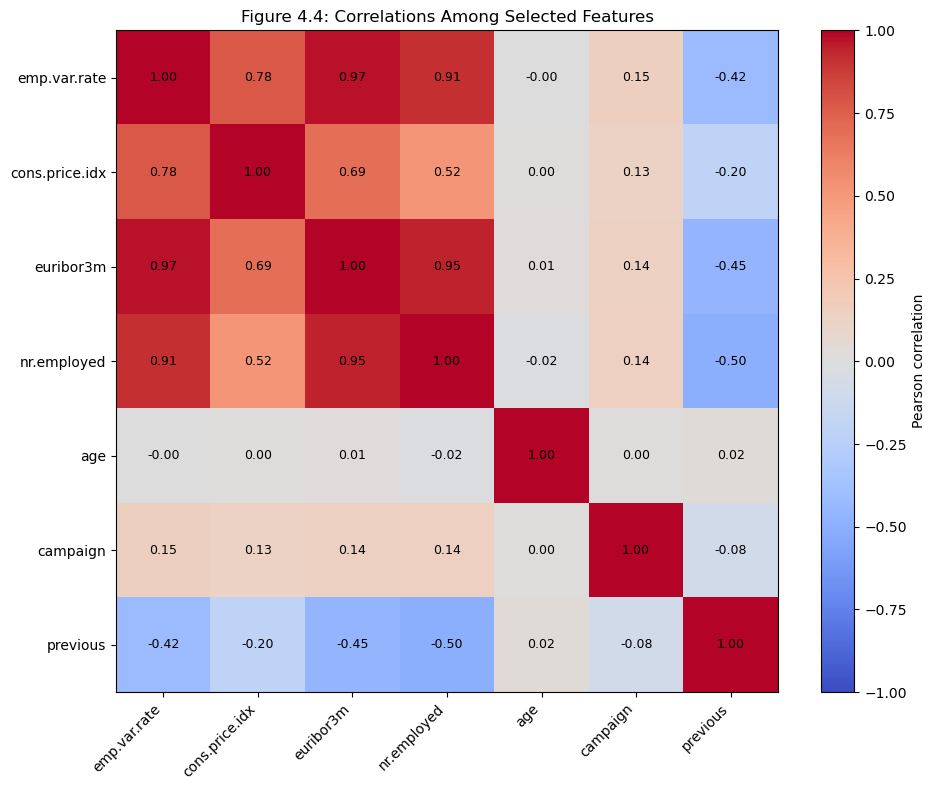

In [30]:

import matplotlib.pyplot as plt

features = [
    "emp.var.rate",
    "cons.price.idx",
    "euribor3m",
    "nr.employed",
    "age",
    "campaign",
    "previous"
]

corr = df[features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Pearson correlation")

plt.xticks(
    range(len(features)), features,
    rotation=45, ha="right"
)
plt.yticks(range(len(features)), features)

# Add correlation values to each cell
for i in range(len(features)):
    for j in range(len(features)):
        plt.text(
            j, i, f"{corr.iloc[i, j]:.2f}",
            ha="center", va="center", fontsize=9
        )

plt.title("Figure 4.4: Correlations Among Selected Features")
plt.tight_layout()
plt.show()
